In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.utils.plotting import plot_simulation_dashboard, plot_benchmarker_results, plot_markov_matrix

from src.solvers import AugmentedHybridSDPSolver, AugmentedBaselineSDPSolver

from src.plants import AugmentedHybridPlant, AugmentedFuelCellOnlyPlant

from src.controllers import (
    build_approach,
    AugmentedFCLockedControl,
    AugmentedPolicyControl,
    AugmentedValueControl,
    AugmentedSDPBaselineControl
)

config = SimConfig()
fleet_data = load_and_cache_entire_fleet(config)

# Initialize benchmarker
exclude_days = [] 
benchmarker = VoyageBenchmarker(fleet_data, config, exclude_days)


⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 400.0 kW
 -> Grid Dimensions    : N_d≈8, N_n=17, N_soc=37, N_fc=9, N_bat=16
 -> Augmented Space |S|: 45,288 states
 -> Action Space |A|   : 272 actions
 -> Est. Big-O Comput. : O(3,804,192,000) operations
 -> Est. RAM Footprint : ~260.00 MB

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [4]:
augmented_approaches = {
    # "MacroFuelCellOnlyBaseline": build_approach(
    #     plant_cls=AugmentedFuelCellOnlyPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=True
    # ),
    # "FuelCellOnlyBaseline": build_approach(
    #     plant_cls=AugmentedFuelCellOnlyPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=False
    # ),
    # "MacroHybridBaseline": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=True
    # ),
    # "HybridBaseline": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=False
    # ),
    "MacroFCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "FCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroPolicy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Policy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroValue": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Value": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
}

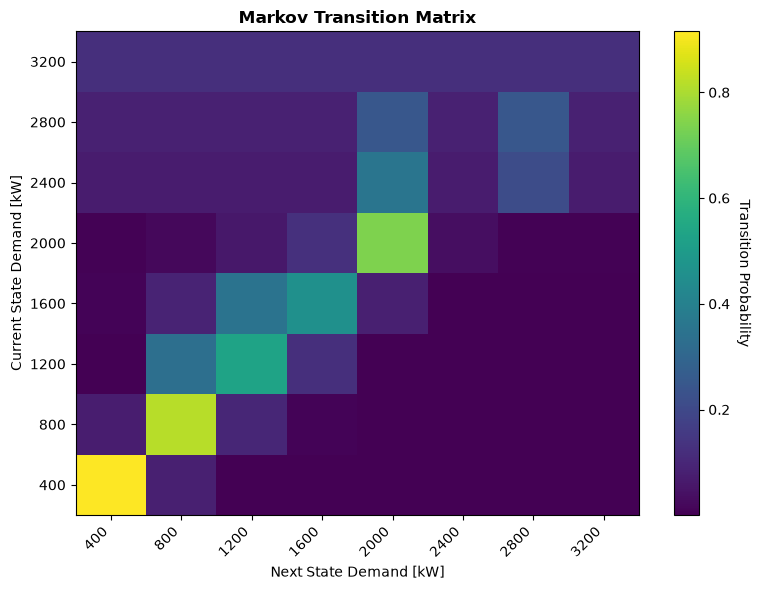

In [5]:
# Manually choose training block and test validation target
train_days = [1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14]
mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
plot_markov_matrix(mc_model)
test_day = 6
approaches = augmented_approaches

--- APPROACH A: HAND-PICKED EVALUATION ---
| Strategy      | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| MacroFCLocked | 8466.29        | 5589.02            | 600.00             | 93.75            | 1980.51            | 75.00                 | 128.01             | 53.96                    | 0.10                    |
| FCLocked      | 8318.98        | 5572.16            | 487.50             | 81.16            | 1872.64            | 187.50                | 118.02             | 53.96                    | 0.47                    |
| MacroPolicy   | 8466.29        | 5589.02            | 600.00             | 93.75            | 1

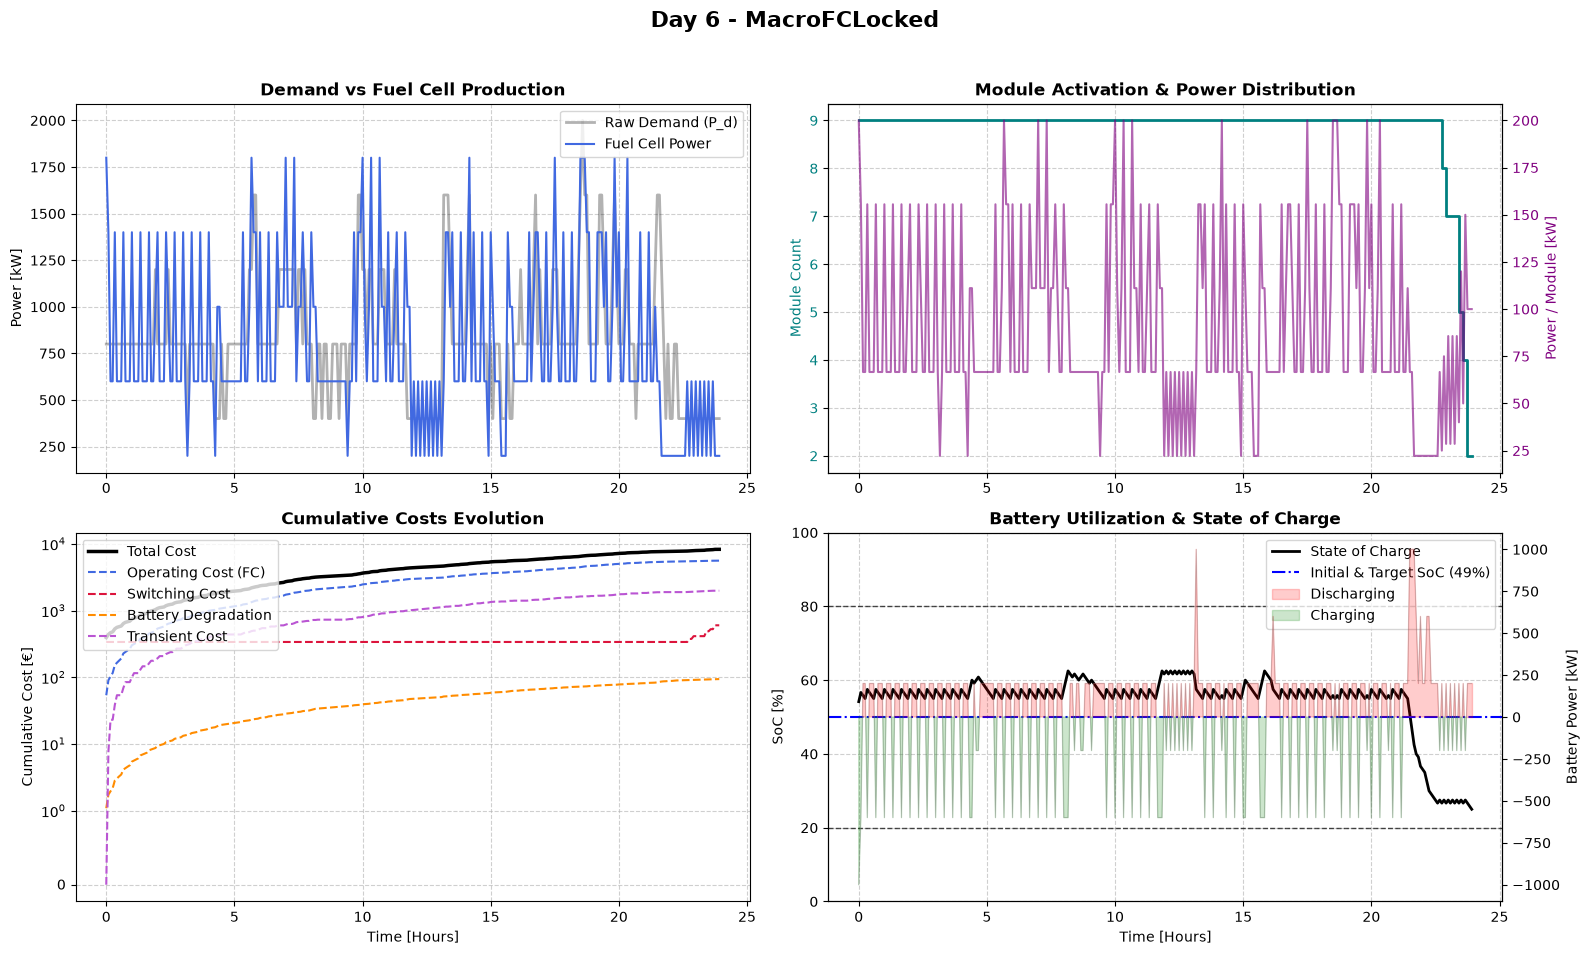

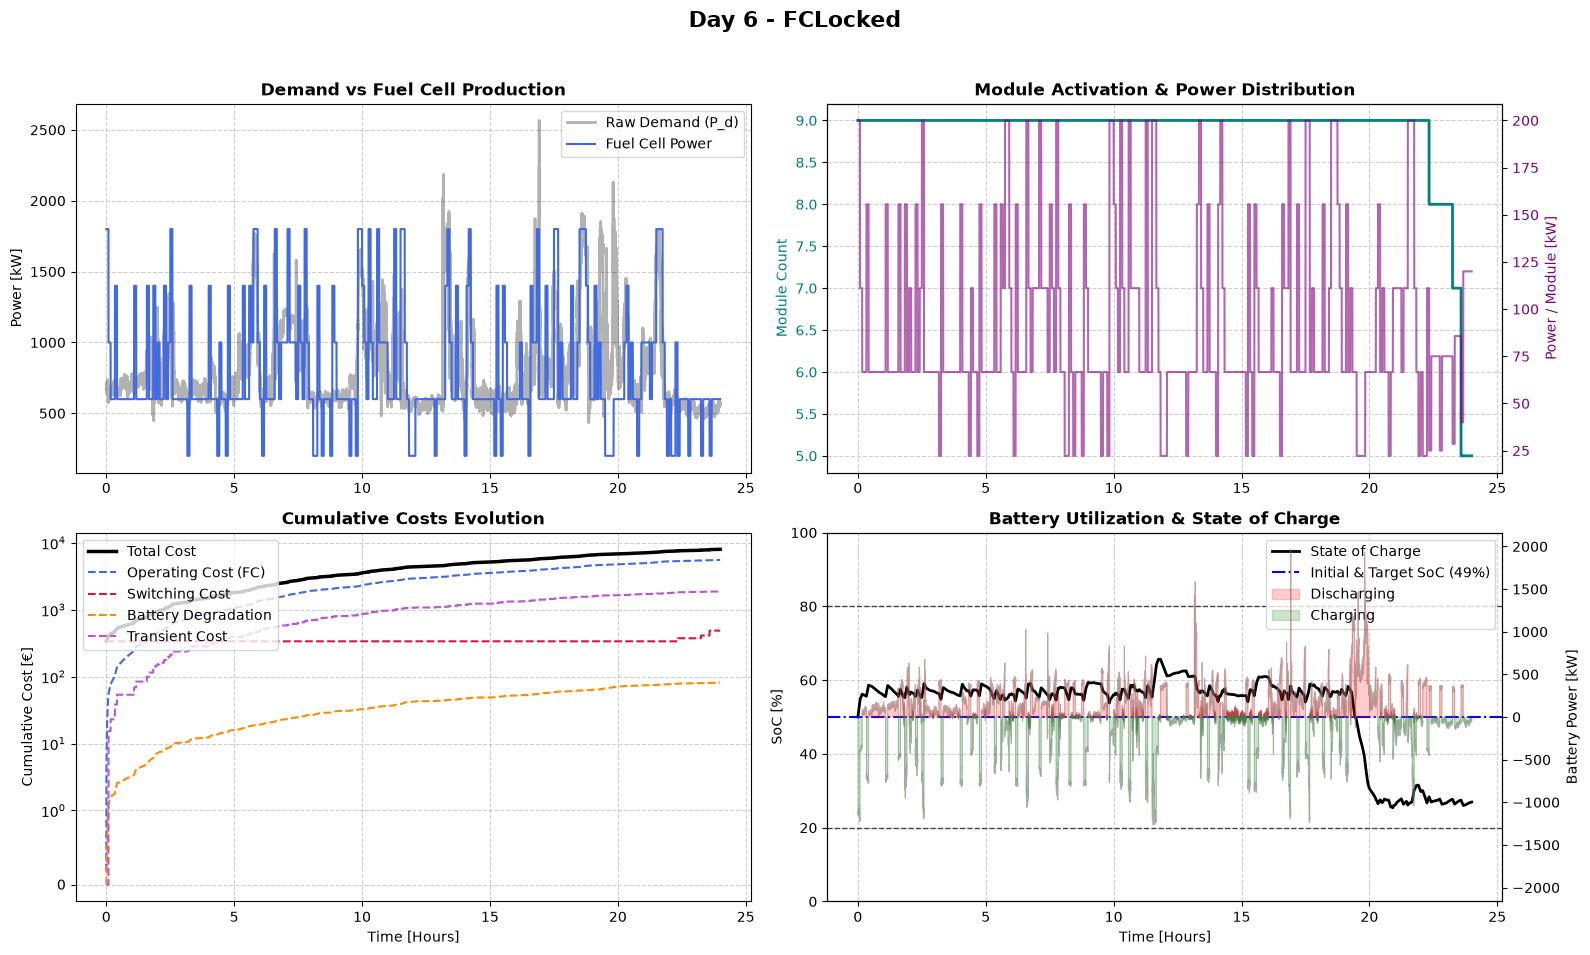

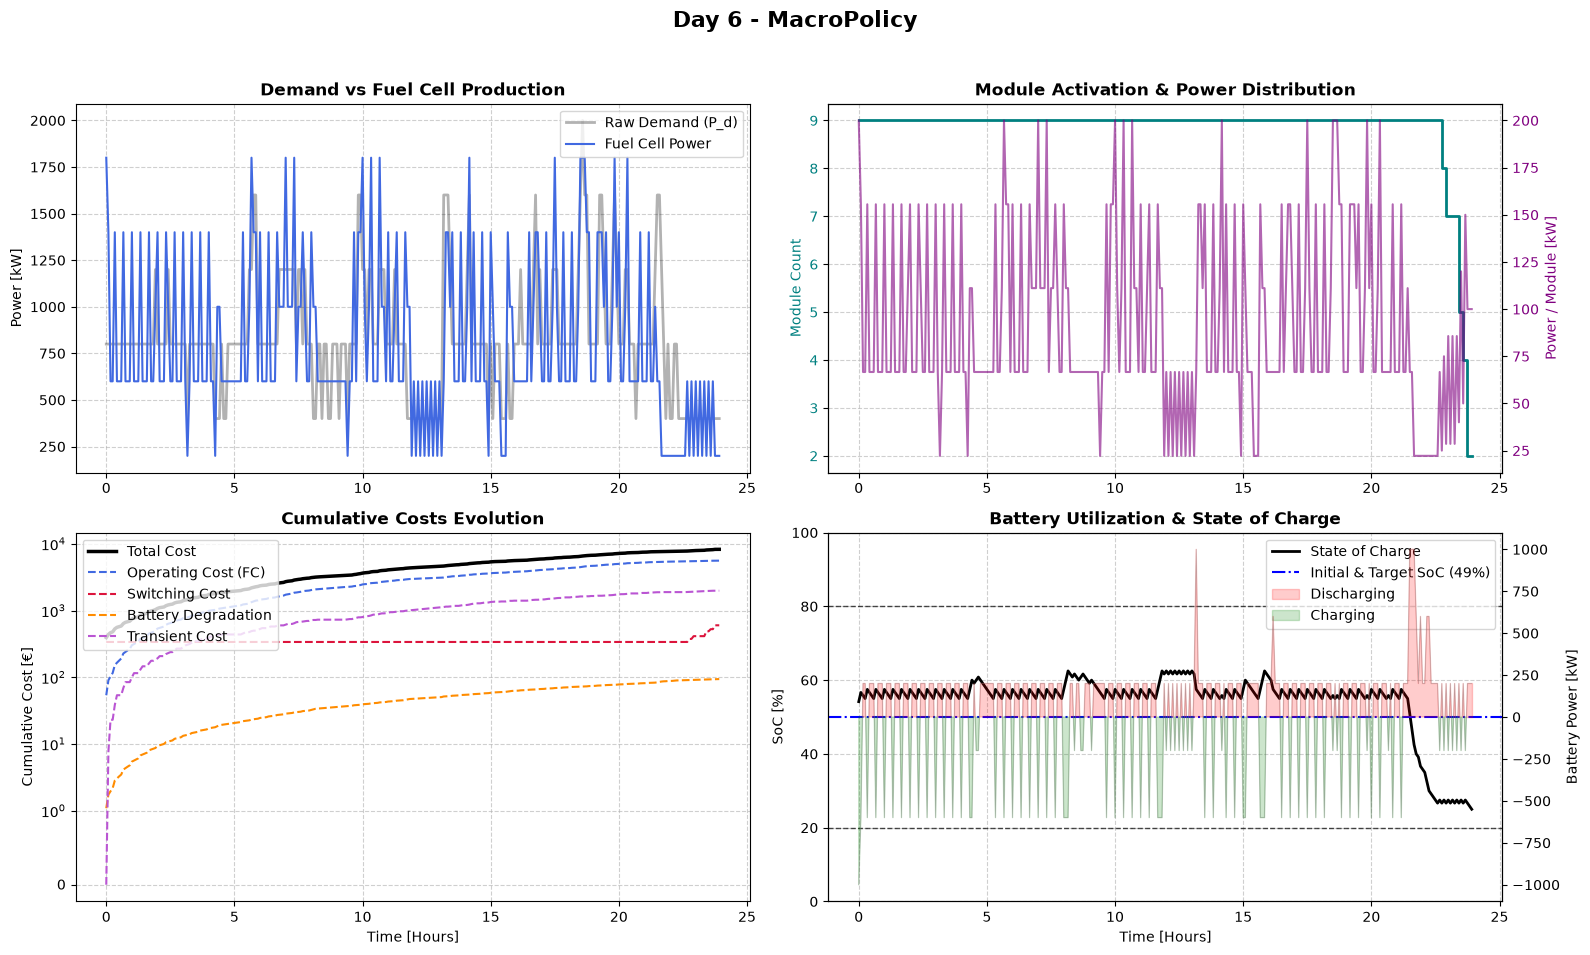

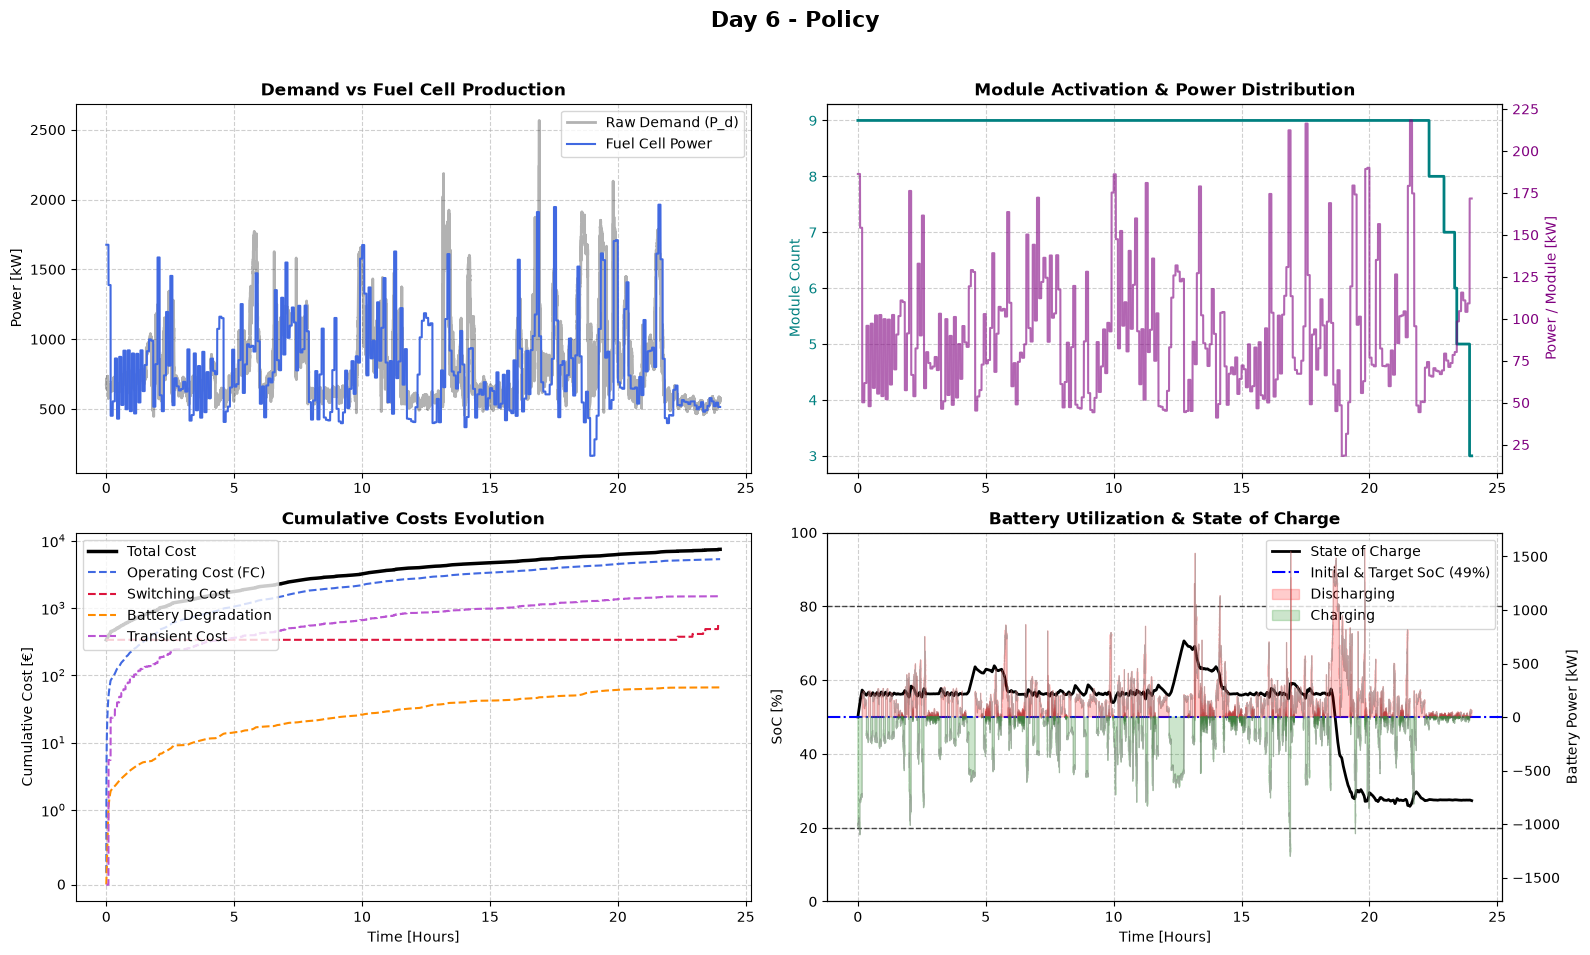

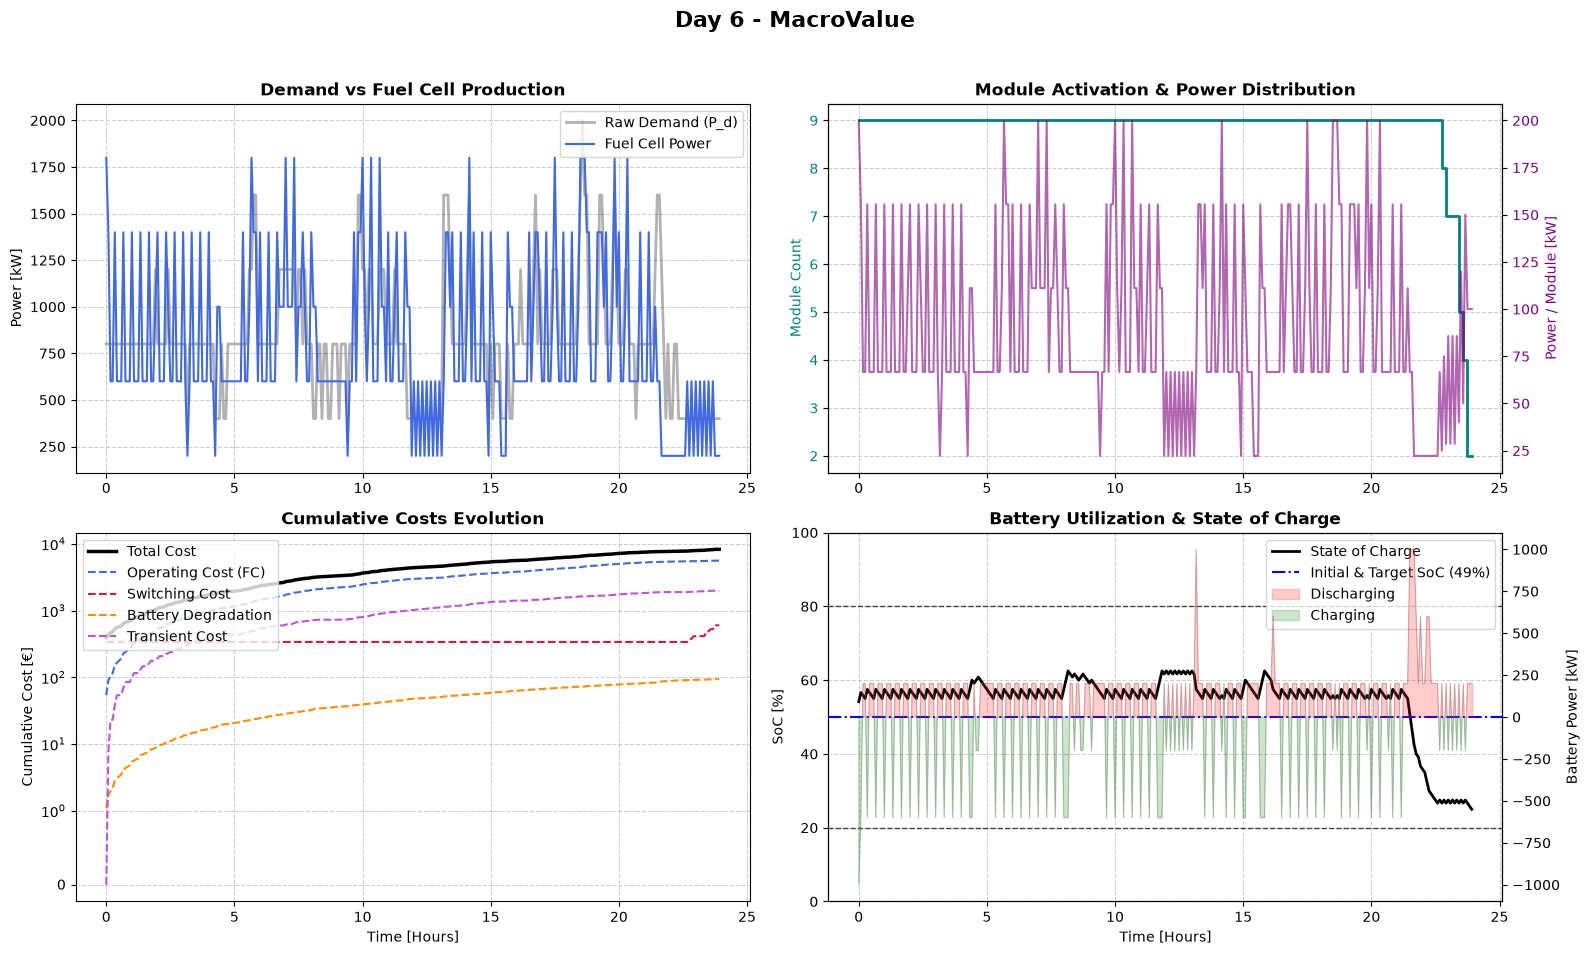

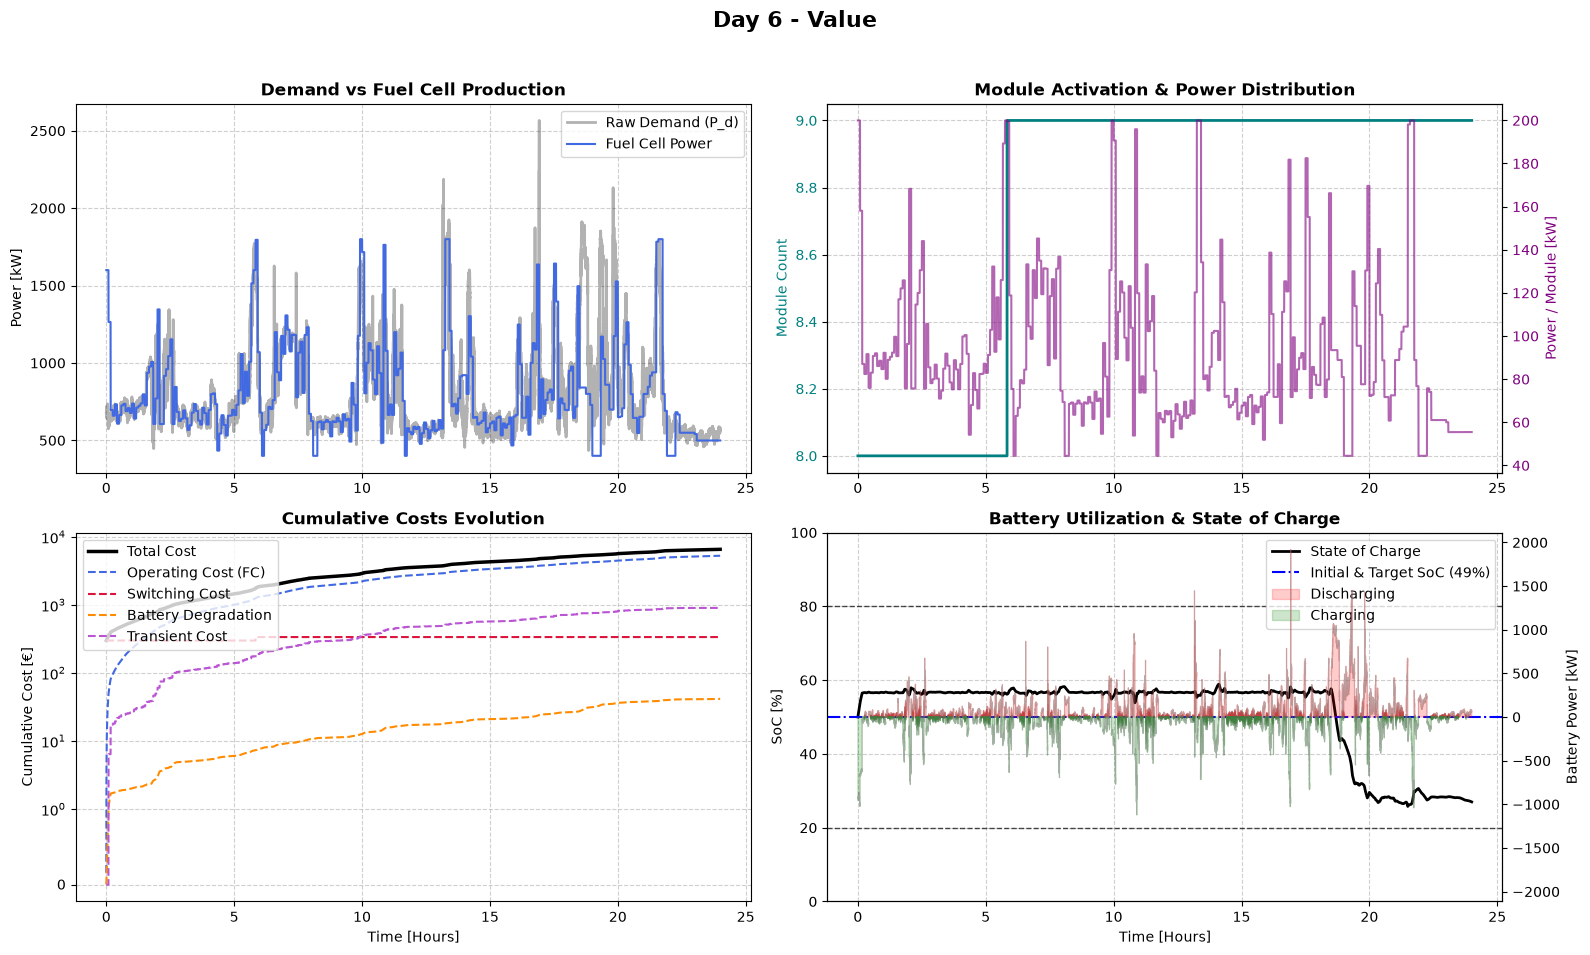

In [6]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")

report = benchmarker.compare_approaches(approaches, train_days, test_day)
print_markdown_table(report.summary)

for app in approaches:
    plot_simulation_dashboard(report.get_telemetry(app), benchmarker.config, title=f"Day {test_day} - {app}", indiv=False)




--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---
 [Vault] Cache MISS: Training Markov Chain for days [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Mar

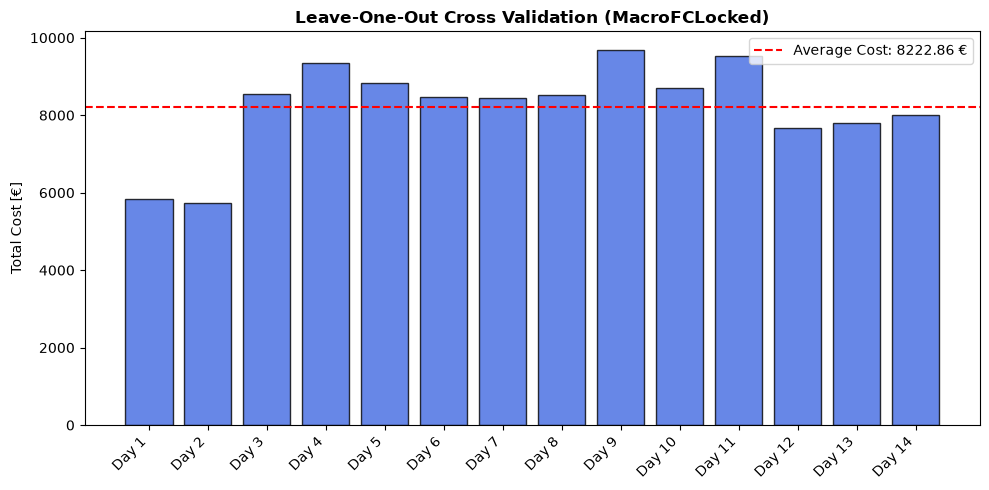

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 5824.47        | 3181.60            | 525.00             | 92.88            | 1967.06            | 75.00                 | -17.07             | 38.94                    | 0.00                    |
| Day 2    | 5727.88        | 3039.85            | 525.00             | 92.01            | 2013.09            | 75.00                 | -17.07             | 46.77                    | 0.00                    |
| Day 3    | 8556.20        | 5444.87            | 487.50             | 99.39            | 2033.32            | 337.50                | 153.62             | 64.

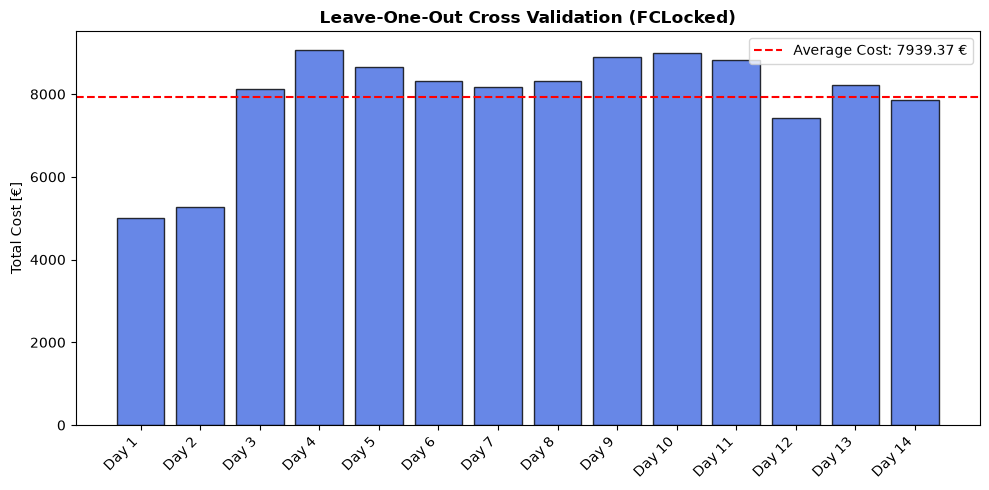

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 5006.42        | 2871.50            | 487.50             | 74.06            | 1469.83            | 112.50                | -8.97              | 38.94                    | 0.28                    |
| Day 2    | 5271.77        | 2868.38            | 487.50             | 82.33            | 1730.84            | 112.50                | -9.79              | 46.77                    | 0.29                    |
| Day 3    | 8122.65        | 5374.17            | 675.00             | 89.39            | 1685.40            | 150.00                | 148.68             | 64.

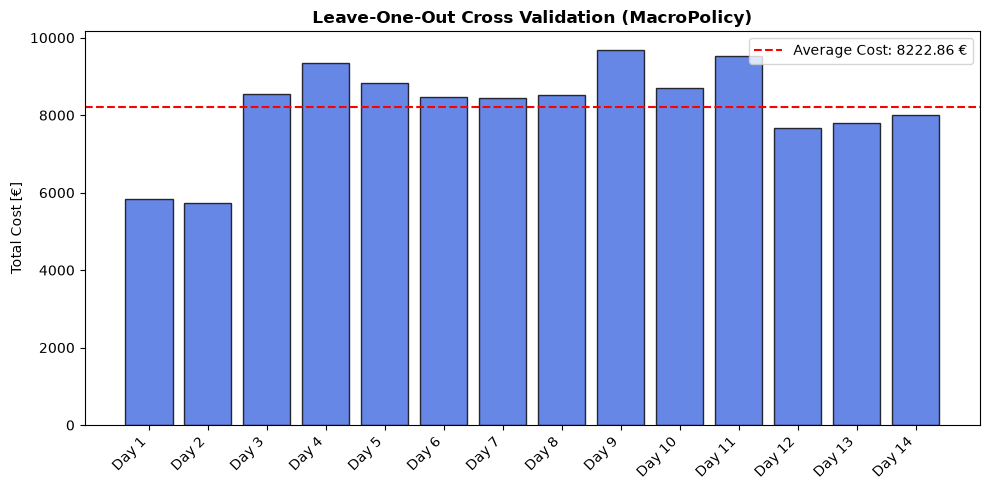

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 5824.47        | 3181.60            | 525.00             | 92.88            | 1967.06            | 75.00                 | -17.07             | 38.94                    | 0.00                    |
| Day 2    | 5727.88        | 3039.85            | 525.00             | 92.01            | 2013.09            | 75.00                 | -17.07             | 46.77                    | 0.00                    |
| Day 3    | 8556.20        | 5444.87            | 487.50             | 99.39            | 2033.32            | 337.50                | 153.62             | 64.

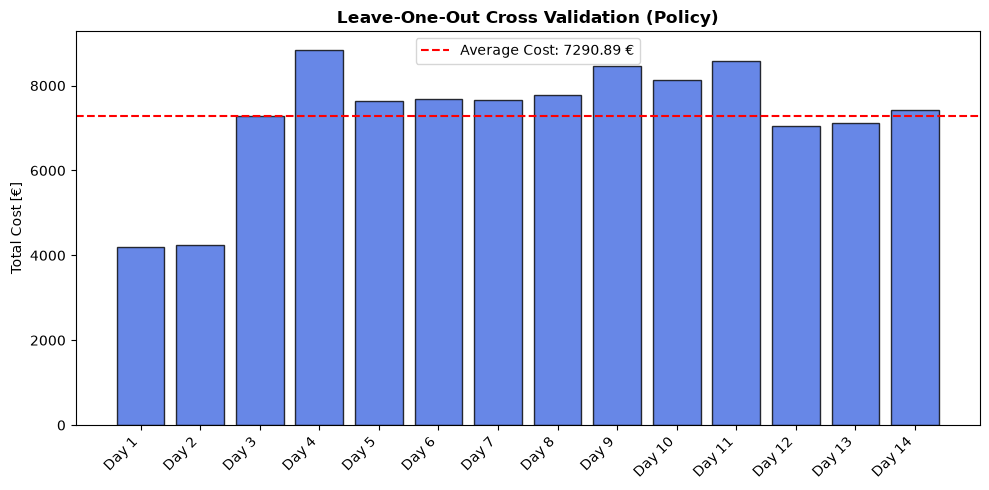

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 4194.40        | 2621.91            | 562.50             | 35.39            | 967.31             | 37.50                 | -30.22             | 38.94                    | 0.28                    |
| Day 2    | 4233.31        | 2613.17            | 487.50             | 36.51            | 1046.25            | 112.50                | -62.62             | 46.77                    | 0.29                    |
| Day 3    | 7273.50        | 5128.38            | 787.50             | 49.26            | 1121.64            | 37.50                 | 149.23             | 64.

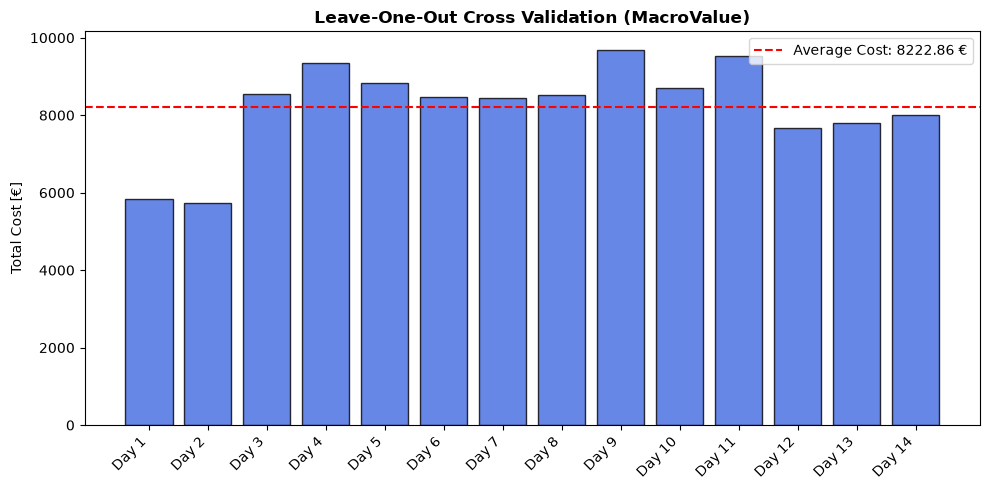

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 5824.47        | 3181.60            | 525.00             | 92.88            | 1967.06            | 75.00                 | -17.07             | 38.94                    | 0.01                    |
| Day 2    | 5727.88        | 3039.85            | 525.00             | 92.01            | 2013.09            | 75.00                 | -17.07             | 46.77                    | 0.01                    |
| Day 3    | 8556.20        | 5444.87            | 487.50             | 99.39            | 2033.32            | 337.50                | 153.62             | 64.

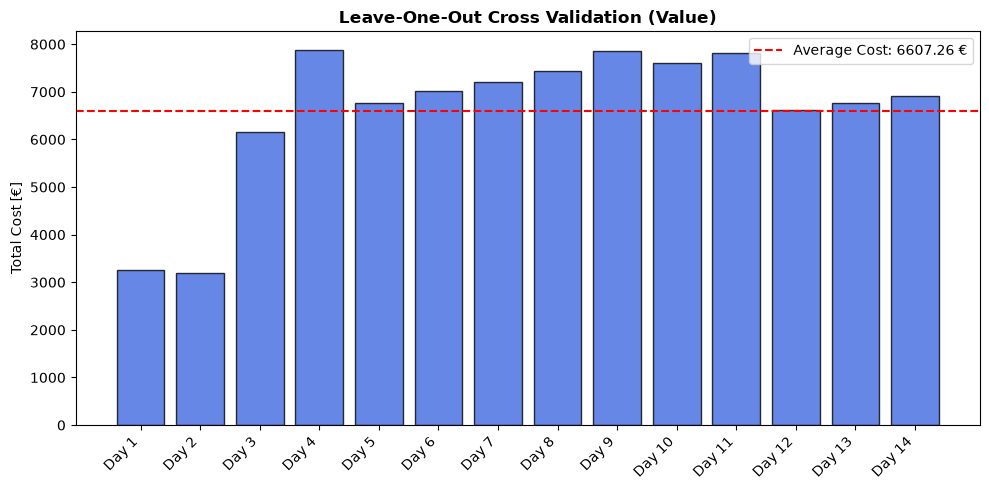

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3267.81        | 2669.56            | 375.00             | 17.68            | 117.86             | 225.00                | -137.29            | 38.94                    | 0.28                    |
| Day 2    | 3196.02        | 2617.90            | 450.00             | 16.45            | 95.03              | 150.00                | -133.36            | 46.77                    | 0.28                    |
| Day 3    | 6146.22        | 5029.27            | 750.00             | 31.92            | 106.54             | 75.00                 | 153.49             | 64.

In [7]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---")

# Note: Running LOO on all 5 approaches might take a couple of minutes due to 4D solves.
# Let's compare the main engineering deployable hybrid against the legacy baseline.

for app in approaches:
# for app in ["Value"]:
    report = benchmarker.run_leave_one_out(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Leave-One-Out Cross Validation ({app})", plot_type='bar')
    print_markdown_table(report.summary)




--- APPROACH C: FORWARD CHAINING (Learning Curve) ---
 [Vault] Cache MISS: Training Markov Chain for days [1]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 5]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 5, 6]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3, 4, 5

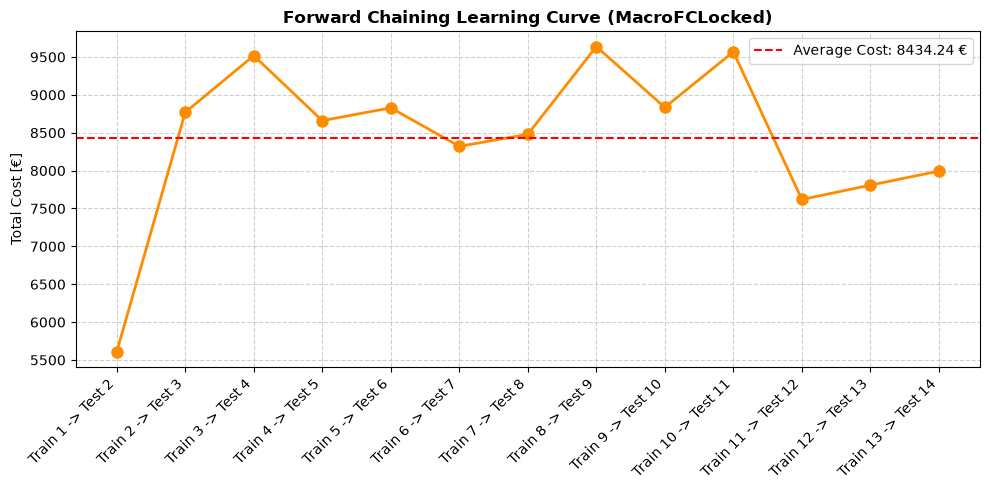

| Strategy            | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Train 1 -> Test 2   | 5608.00        | 3218.85            | 300.00             | 94.18            | 1937.04            | 75.00                 | -17.07             | 38.68                    | 0.00                    |
| Train 2 -> Test 3   | 8769.53        | 5618.12            | 675.00             | 102.00           | 2070.80            | 150.00                | 153.62             | 39.24                    | 0.00                    |
| Train 3 -> Test 4   | 9517.85        | 6535.84            | 1162.50            | 98.96            | 1565.38       

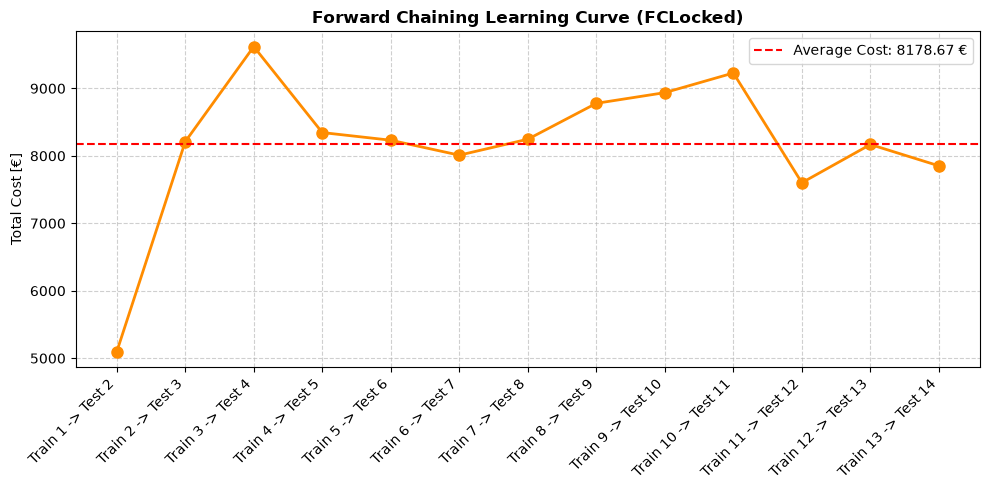

| Strategy            | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Train 1 -> Test 2   | 5094.94        | 2993.45            | 300.00             | 83.95            | 1660.86            | 75.00                 | -18.32             | 38.68                    | 0.28                    |
| Train 2 -> Test 3   | 8209.89        | 5330.19            | 787.50             | 93.22            | 1662.80            | 187.50                | 148.68             | 39.24                    | 0.34                    |
| Train 3 -> Test 4   | 9619.45        | 6540.97            | 1275.00            | 109.51           | 1534.82       

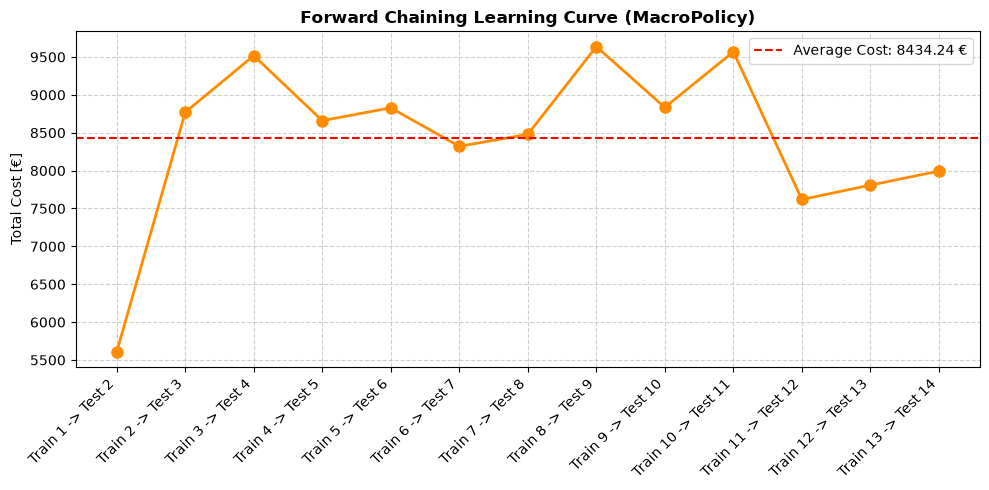

| Strategy            | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Train 1 -> Test 2   | 5608.00        | 3218.85            | 300.00             | 94.18            | 1937.04            | 75.00                 | -17.07             | 38.68                    | 0.00                    |
| Train 2 -> Test 3   | 8769.53        | 5618.12            | 675.00             | 102.00           | 2070.80            | 150.00                | 153.62             | 39.24                    | 0.00                    |
| Train 3 -> Test 4   | 9517.85        | 6535.84            | 1162.50            | 98.96            | 1565.38       

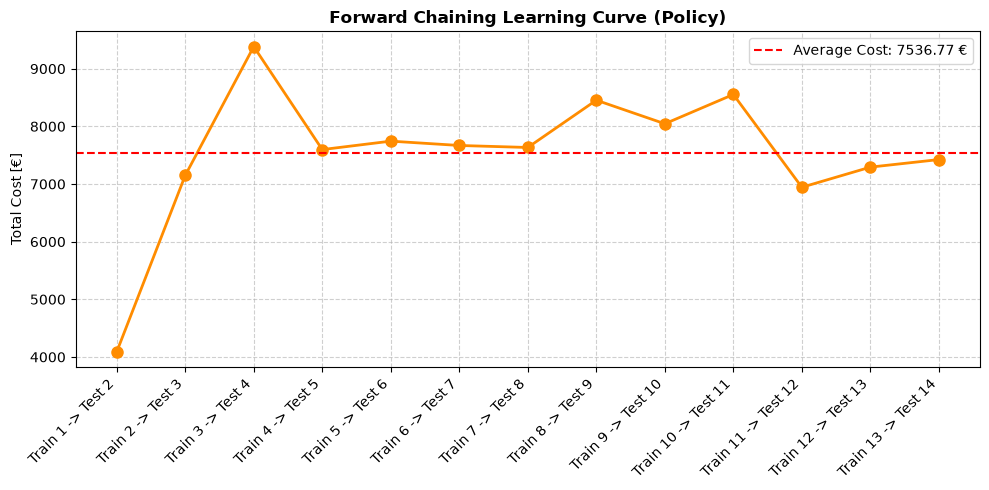

| Strategy            | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Train 1 -> Test 2   | 4089.34        | 2537.92            | 300.00             | 41.23            | 1186.72            | 75.00                 | -51.52             | 38.68                    | 0.37                    |
| Train 2 -> Test 3   | 7149.44        | 4912.48            | 525.00             | 46.46            | 1084.06            | 450.00                | 131.44             | 39.24                    | 0.46                    |
| Train 3 -> Test 4   | 9383.51        | 6474.72            | 1462.50            | 91.88            | 1279.99       

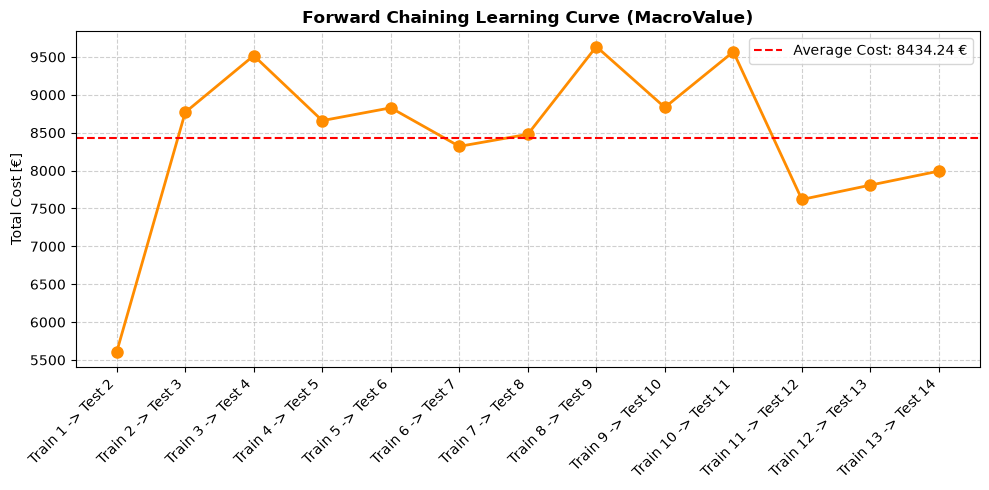

| Strategy            | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Train 1 -> Test 2   | 5608.00        | 3218.85            | 300.00             | 94.18            | 1937.04            | 75.00                 | -17.07             | 38.68                    | 0.01                    |
| Train 2 -> Test 3   | 8769.53        | 5618.12            | 675.00             | 102.00           | 2070.80            | 150.00                | 153.62             | 39.24                    | 0.01                    |
| Train 3 -> Test 4   | 9517.85        | 6535.84            | 1162.50            | 98.96            | 1565.38       

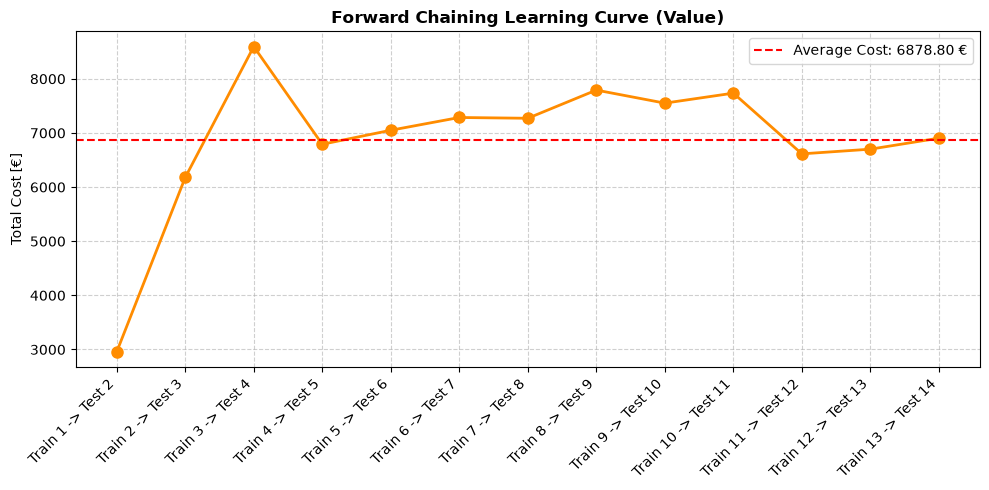

| Strategy            | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Train 1 -> Test 2   | 2956.82        | 2429.72            | 262.50             | 11.38            | 208.15             | 112.50                | -67.43             | 38.68                    | 0.38                    |
| Train 2 -> Test 3   | 6177.85        | 4998.35            | 825.00             | 25.01            | 176.66             | 0.00                  | 152.82             | 39.24                    | 0.35                    |
| Train 3 -> Test 4   | 8595.32        | 6646.72            | 1275.00            | 75.20            | 575.53        

In [8]:
print("\n--- APPROACH C: FORWARD CHAINING (Learning Curve) ---")
# Evaluate how the policy improves as the agent gathers chronological data
# Using the Lookahead Optimum to see the absolute theoretical ceiling of the ship's capabilities

for app in approaches:
# for app in ["Value"]:
    report = benchmarker.run_forward_chaining(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Forward Chaining Learning Curve ({app})", plot_type='line')
    print_markdown_table(report.summary)